<a href="https://colab.research.google.com/github/jitishakarnani/data-projects/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()
df.shape

(891, 12)

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Fill Age with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column
df.drop(columns=['Cabin'], inplace=True)

# Verify - should show all zeros now (except Cabin which is gone)
df.isnull().sum()

/tmp/ipykernel_3647/3142635656.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_3647/3142635656.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


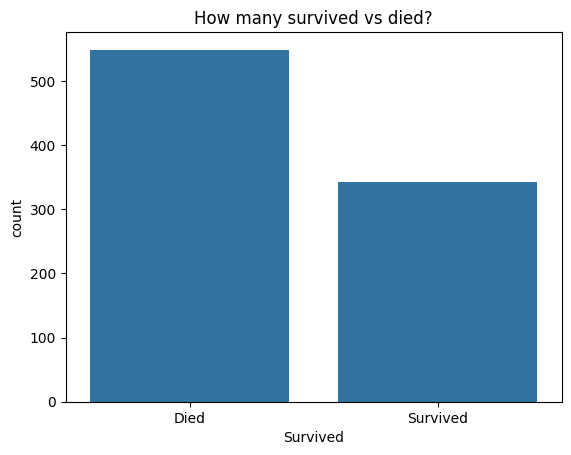

In [7]:
sns.countplot(x='Survived', data=df)
plt.title('How many survived vs died?')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

In [8]:
import plotly.express as px

fig = px.histogram(df, x='Survived', color='Survived',
             title='How many survived vs died?',
             labels={'Survived': 'Status', 'count': 'Number of Passengers'},
             color_discrete_map={0: 'red', 1: 'green'},
             category_orders={'Survived': [0, 1]})

fig.update_xaxes(ticktext=['Died', 'Survived'], tickvals=[0, 1])
fig.show()

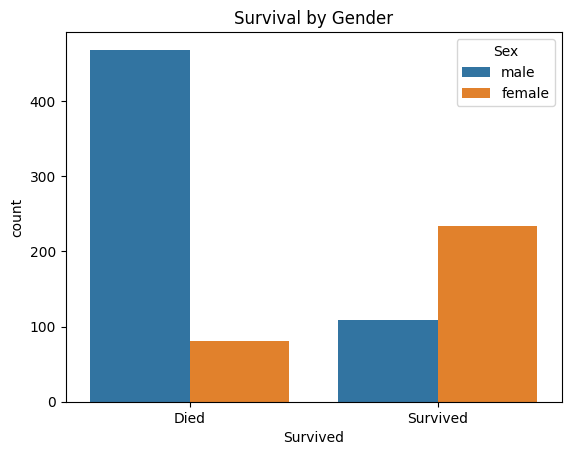

In [9]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

In [10]:
fig = px.histogram(df, x='Survived', color='Sex',
             title='Survival by Gender',
             barmode='group',
             labels={'Survived': 'Status'},
             color_discrete_map={'male': 'blue', 'female': 'orange'},
             category_orders={'Survived': [0, 1]})

fig.update_xaxes(ticktext=['Died', 'Survived'], tickvals=[0, 1])
fig.show()

In [11]:
fig = px.histogram(df, x='Survived', color='Pclass',
             title='Survival by Ticket Class',
             barmode='group',
             labels={'Survived': 'Status', 'Pclass': 'Class'},
             category_orders={'Survived': [0, 1]},
             color_discrete_map={1: 'gold', 2: 'silver', 3: 'brown'})

fig.update_xaxes(ticktext=['Died', 'Survived'], tickvals=[0, 1])
fig.show()

In [12]:
# Convert Sex to numbers: male=0, female=1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Convert Embarked to numbers: S=0, C=1, Q=2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Check the result
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


In [13]:
# Select only useful columns
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features]  # Input (what we know)
y = df['Survived']  # Output (what we want to predict)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 7)
y shape: (891,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (712, 7)
Testing size: (179, 7)


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


In [16]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 82.68%


In [17]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

fig = px.bar(importance,
             title='Which factors affected survival the most?',
             labels={'index': 'Factor', 'value': 'Importance'})
fig.show()

In [18]:
# Let's predict YOUR survival on the Titanic!
# Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
my_data = [[3, 1, 20, 0, 0, 7.25, 0]]  # Poor, female, 20yrs old

prediction = model.predict(my_data)

if prediction[0] == 1:
    print("✅ You would have SURVIVED!")
else:
    print("❌ You would have DIED!")

✅ You would have SURVIVED!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



In [19]:
# Let's predict YOUR survival on the Titanic!
# Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
my_data = [[3, 0, 20, 0, 0, 7.25, 0]]  # Poor, male, 20yrs old

prediction = model.predict(my_data)

if prediction[0] == 1:
    print("✅ You would have SURVIVED!")
else:
    print("❌ You would have DIED!")

❌ You would have DIED!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

